In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score
from preprocessing import get_features_and_target
from visualizer import plot_visualizer, plot_visualizer_classification
import plotly.graph_objects as go
from sklearn.model_selection import StratifiedKFold
from preprocessing import get_features_and_target_classification
from tabpfn import TabPFNClassifier, TabPFNRegressor
import matplotlib.pyplot as plt

In [2]:
import huggingface_hub
huggingface_hub.login()

# Getting Dataframe

In [ ]:
# Load the training and development datasets
train_df = pd.read_csv("data/train_data.csv")
dev_df = pd.read_csv("data/development_data.csv")
#sc = StandardScaler()

target_column_class = "Category" 


x_train, y_train  = get_features_and_target(train_df, target_column_class)
x_dev, y_dev = get_features_and_target(dev_df, target_column_class)

#x_train = sc.fit_transform(X=x_train)
#x_dev = sc.transform(x_dev)

In [4]:
x_train

,Pressure (PSI),Welding Time (ms),Angle (Deg),Force (N),Current (A),Thickness A (mm),Thickness B (mm)
0,35,200,0,6.82,1081.47,0.922,0.920
1,35,1500,0,52.25,2014.73,0.920,0.925
2,95,200,0,16.57,1321.93,0.912,0.924
3,95,200,0,41.42,1615.83,0.948,0.939
4,35,1500,0,63.82,1137.29,0.930,0.937
...,...,...,...,...,...,...,...
271,60,1200,0,98.29,3506.33,0.632,0.627
272,60,1200,0,98.04,4226.94,0.647,0.624
273,60,1200,0,98.07,3601.67,0.666,0.633
274,60,1200,0,97.09,4161.74,0.615,0.619


# Add Physical Columns Interfacial_Failure and Pullout_Failure

In [5]:
def compute_interfacial_failure(df):
     t = df[['Thickness A (mm)', 'Thickness B (mm)']].min(axis=1) 
     f_pull = 1 * (np.pi/4) * (4 * np.sqrt(t))**2 * (0.7 * 365) 
     return np.round(f_pull, 1) 

def compute_pullout_failure(df):
     t = df[['Thickness A (mm)', 'Thickness B (mm)']].min(axis=1) 
     x = df[['Thickness A (mm)', 'Thickness B (mm)']].sum(axis=1)
     # x can be approximated to metal sheet thickness. Change 2*t either to t to use the thinner 
     # metal sheet or 2*x to test if the sum of both metal sheets give beter results
     f_pull = np.pi * ((4 * np.sqrt(t)) + 2*t)*t*365 
     return np.round(f_pull, 1) 

In [6]:
x_dev

,Pressure (PSI),Welding Time (ms),Angle (Deg),Force (N),Current (A),Thickness A (mm),Thickness B (mm)
0,95,1500,0,124.19,1045.90,0.918,0.925
1,35,200,0,6.58,1171.55,0.931,0.922
2,35,200,0,6.61,916.16,0.936,0.927
3,35,200,15,27.19,1191.93,0.933,0.927
4,95,1500,15,133.53,1304.90,0.949,0.994
...,...,...,...,...,...,...,...
88,60,1200,0,96.79,4293.96,0.621,0.625
89,60,1200,0,97.29,4226.13,0.634,0.625
90,60,1200,0,97.29,4311.15,0.623,0.630
91,60,1200,0,97.12,4738.77,0.612,0.622


# Fit Model

In [7]:
# Target value

classifier = TabPFNClassifier() 

classifier.fit(x_train,y_train)

predictions_class_train = classifier.predict(x_train)
predictions_class_dev = classifier.predict(x_dev)



# Add Pullforce as Target

In [8]:
def compute_pullforces(x, y, predictions_class):
    pullforces = []

    for sample_id, pred in zip(y.index, predictions_class):
        row_x_df = x.loc[[sample_id]]  # 1-row DataFrame

        if pred == "Bad":
            value = compute_interfacial_failure(row_x_df).iloc[0]
        else:
            value = compute_pullout_failure(row_x_df).iloc[0]

        pullforces.append(value)

    return np.array(pullforces)


In [9]:
predictions_class_train = classifier.predict(x_train)
pullforces_train = compute_pullforces(x_train, y_train, predictions_class_train)


predictions_class_dev = classifier.predict(x_dev)
pullforces_dev = compute_pullforces(x_dev, y_dev, predictions_class_dev)


In [10]:
print(predictions_class_dev)

['Good' 'Bad' 'Bad' 'Bad' 'Good' 'Bad' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good' 'Good'
 'Good' 'Good']


In [11]:
print(pullforces_dev)

[5967.  2960.3 2976.3 2976.3 6305.8 3018.1 3170.5 3245.7 3287.8 3287.8
 3237.3 3254.1 3304.7 3287.8 3262.5 3087.8 3145.6 3330.1 3245.7 3220.5
 3145.6 3237.3 3170.5 3203.8 3220.5 3270.9 3262.5 3254.1 3120.8 3104.3
 3079.6 3162.2 3195.5 3254.1 3262.5 3096.  3129.  3212.2 3071.3 3228.9
 3178.8 3254.1 3153.9 3203.8 3212.2 3203.8 3254.1 3162.2 3120.8 3063.1
 3178.8 3187.1 3162.2 3145.6 3137.3 3170.5 3120.8 3162.2 3220.5 3178.8
 3129.  3153.9 3153.9 3104.3 3055.  3104.3 3228.9 3153.9 3153.9 3178.8
 3104.3 3129.  3137.3 3120.8 3137.3 3112.5 3162.2 3120.8 3145.6 3096.
 3162.2 3187.1 3145.6 3071.3 3038.6 3096.  3055.  3046.8 3129.  3162.2
 3145.6 3055.  3187.1]


In [12]:
y_train_Regressor = train_df.groupby("Sample ID")['PullTest (N)'].first()
y_train_delta =  pullforces_train - y_train_Regressor

y_dev_Regressor = dev_df.groupby("Sample ID")['PullTest (N)'].first()
y_dev_delta = pullforces_dev - y_dev_Regressor


In [13]:
y_train_Regressor.head(10)

Sample ID
1     2127.7
2     5346.4
4     2350.4
5     2174.8
7     3897.5
9     1932.5
10    4174.4
11    3816.0
12    1832.5
14    3970.1
Name: PullTest (N), dtype: float64

In [14]:
pullforces_train

array([2953.9, 5988.6, 2928.2, 3014.9, 6097.2, 2979.5, 6086.3, 6064.5,
       2937.8, 6042.8, 6108.1, 3005.2, 2969.9, 2969.9, 2979.5, 6162.7,
       2966.7, 3423.9, 3195.5, 3279.3, 3178.8, 3321.6, 3120.8, 3203.8,
       3178.8, 3195.5, 3228.9, 3270.9, 3245.7, 3212.2, 3262.5, 3212.2,
       3212.2, 3212.2, 3120.8, 3279.3, 3096. , 3137.3, 3087.8, 3145.6,
       3195.5, 3153.9, 3178.8, 3203.8, 3137.3, 3162.2, 3270.9, 3162.2,
       3220.5, 3245.7, 3162.2, 3187.1, 3262.5, 3254.1, 3220.5, 3237.3,
       3237.3, 3220.5, 3338.6, 3228.9, 3304.7, 3245.7, 3178.8, 3145.6,
       3145.6, 3153.9, 3220.5, 3153.9, 3162.2, 3162.2, 3228.9, 3195.5,
       3137.3, 3237.3, 3145.6, 3245.7, 3187.1, 3087.8, 3112.5, 3129. ,
       3104.3, 3071.3, 3162.2, 3096. , 3120.8, 3087.8, 3055. , 3087.8,
       3112.5, 3245.7, 3195.5, 3162.2, 3304.7, 3145.6, 3079.6, 3212.2,
       3245.7, 3262.5, 3262.5, 3212.2, 3237.3, 3195.5, 3237.3, 3220.5,
       3212.2, 3212.2, 3162.2, 3237.3, 3245.7, 3254.1, 3220.5, 3228.9,
      

In [15]:
y_train_delta.head(10)

Sample ID
1      826.2
2      642.2
4      577.8
5      840.1
7     2199.7
9     1047.0
10    1911.9
11    2248.5
12    1105.3
14    2072.7
Name: PullTest (N), dtype: float64

In [16]:
x_train

,Pressure (PSI),Welding Time (ms),Angle (Deg),Force (N),Current (A),Thickness A (mm),Thickness B (mm)
0,35,200,0,6.82,1081.47,0.922,0.920
1,35,1500,0,52.25,2014.73,0.920,0.925
2,95,200,0,16.57,1321.93,0.912,0.924
3,95,200,0,41.42,1615.83,0.948,0.939
4,35,1500,0,63.82,1137.29,0.930,0.937
...,...,...,...,...,...,...,...
271,60,1200,0,98.29,3506.33,0.632,0.627
272,60,1200,0,98.04,4226.94,0.647,0.624
273,60,1200,0,98.07,3601.67,0.666,0.633
274,60,1200,0,97.09,4161.74,0.615,0.619


# Fit 2nd Model

In [17]:
# Initialize the regressor
regressor = TabPFNRegressor()  # Uses TabPFN-2.5 weights, trained on synthetic data only.
# To use TabPFN v2:
# regressor = TabPFNRegressor.create_default_for_version(ModelVersion.V2)


regressor.fit(x_train, y_train_delta)

# Predict on the test set
predictions_class_dev = regressor.predict(x_dev)
    

final_pred = pullforces_dev + predictions_class_dev

pred_series = pd.Series(predictions_class_dev, index=x_dev.index)
pull_series = pd.Series(pullforces_dev, index=y_dev.index)

final_pred = pull_series.loc[pred_series.index] - pred_series


In [18]:
pred_series

0     2109.569336
1      795.076721
2      826.075073
3      723.036804
4     1623.719727
         ...     
88     240.062454
89     238.872360
90     250.054245
91     300.048767
92     232.856903
Length: 93, dtype: float32

In [19]:
pull_series

0     5967.0
1     2960.3
2     2976.3
3     2976.3
4     6305.8
       ...  
88    3129.0
89    3162.2
90    3145.6
91    3055.0
92    3187.1
Length: 93, dtype: float64

In [20]:
pullforces_dev

array([5967. , 2960.3, 2976.3, 2976.3, 6305.8, 3018.1, 3170.5, 3245.7,
       3287.8, 3287.8, 3237.3, 3254.1, 3304.7, 3287.8, 3262.5, 3087.8,
       3145.6, 3330.1, 3245.7, 3220.5, 3145.6, 3237.3, 3170.5, 3203.8,
       3220.5, 3270.9, 3262.5, 3254.1, 3120.8, 3104.3, 3079.6, 3162.2,
       3195.5, 3254.1, 3262.5, 3096. , 3129. , 3212.2, 3071.3, 3228.9,
       3178.8, 3254.1, 3153.9, 3203.8, 3212.2, 3203.8, 3254.1, 3162.2,
       3120.8, 3063.1, 3178.8, 3187.1, 3162.2, 3145.6, 3137.3, 3170.5,
       3120.8, 3162.2, 3220.5, 3178.8, 3129. , 3153.9, 3153.9, 3104.3,
       3055. , 3104.3, 3228.9, 3153.9, 3153.9, 3178.8, 3104.3, 3129. ,
       3137.3, 3120.8, 3137.3, 3112.5, 3162.2, 3120.8, 3145.6, 3096. ,
       3162.2, 3187.1, 3145.6, 3071.3, 3038.6, 3096. , 3055. , 3046.8,
       3129. , 3162.2, 3145.6, 3055. , 3187.1])

In [21]:
final_pred

0     3857.430664
1     2165.223279
2     2150.224927
3     2253.263196
4     4682.080273
         ...     
88    2888.937546
89    2923.327640
90    2895.545755
91    2754.951233
92    2954.243097
Length: 93, dtype: float64

In [22]:
y_dev

0     Good
1      Bad
2      Bad
3      Bad
4     Good
      ... 
88    Good
89    Good
90    Good
91    Good
92    Good
Name: Category, Length: 93, dtype: object

# Check Validation Data

In [23]:
# Category array (must be aligned with y_dev)
categories = dev_df.groupby("Sample ID")["Category"].first().values

plot_visualizer(
    true_vals=y_dev_Regressor,
    pred_vals=final_pred,
    categories=categories,
    title=f"Validation Samples: True vs Prediction (TabPFN) by Category"
)

# Check Validation Loss and R2

In [24]:
# Calculate MAE and RMSE and R2
mae  = mean_absolute_error(y_dev_Regressor, final_pred)
rmse = np.sqrt(mean_squared_error(y_dev_Regressor, final_pred))
R2   = r2_score(y_dev_Regressor, final_pred)


print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {R2:.2f}")

MAE:  133.13
RMSE: 217.83
R2: 0.63

MAE:  109.67
RMSE: 161.69
R2: 0.79


# Cross Validation

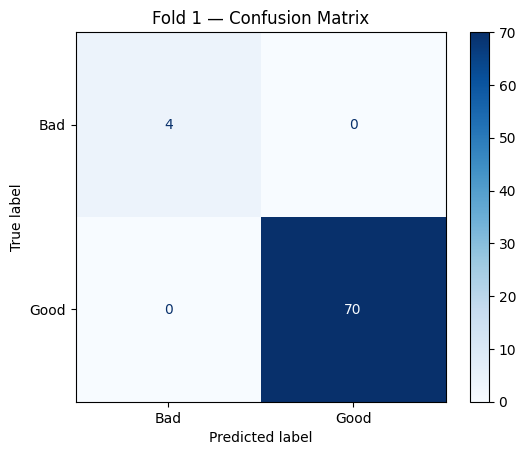

F1 Score: 1.0
     Pressure (PSI)  Welding Time (ms)  Angle (Deg)  Force (N)  Current (A)  \
1                35               1500            0      52.25      2014.73   
3                95                200            0      41.42      1615.83   
5                35                200            0      16.47      1083.06   
7                95               1500            0     129.13      1112.82   
8                95                200            0      16.55      1357.87   
..              ...                ...          ...        ...          ...   
364              60               1200            0      96.79      4293.96   
365              60               1200            0      97.29      4226.13   
366              60               1200            0      97.29      4311.15   
367              60               1200            0      97.12      4738.77   
368              60               1200            0      97.35      3971.85   

     Thickness A (mm)  Thickness B (m


Fold 1
MAE : 150.11269647752917
RMSE: 272.4122045066208
R²  : 0.32540227876392425


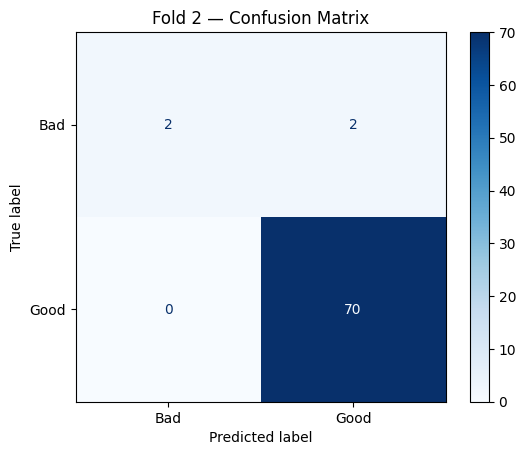

F1 Score: 0.8262910798122065
     Pressure (PSI)  Welding Time (ms)  Angle (Deg)  Force (N)  Current (A)  \
0                35                200            0       6.82      1081.47   
1                35               1500            0      52.25      2014.73   
2                95                200            0      16.57      1321.93   
4                35               1500            0      63.82      1137.29   
5                35                200            0      16.47      1083.06   
..              ...                ...          ...        ...          ...   
364              60               1200            0      96.79      4293.96   
365              60               1200            0      97.29      4226.13   
366              60               1200            0      97.29      4311.15   
367              60               1200            0      97.12      4738.77   
368              60               1200            0      97.35      3971.85   

     Thickness A (mm) 


Fold 2
MAE : 128.56570528391242
RMSE: 239.61666136516467
R²  : 0.6491201584434558


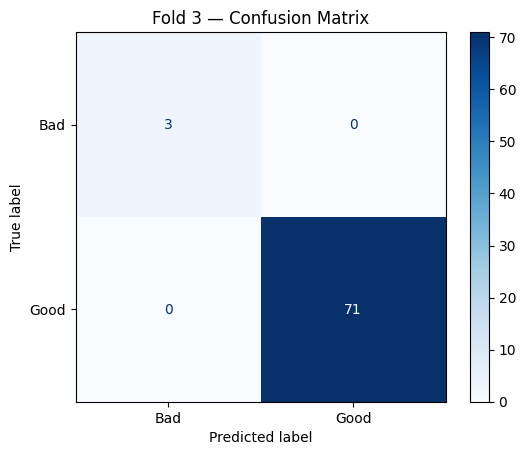

F1 Score: 1.0
     Pressure (PSI)  Welding Time (ms)  Angle (Deg)  Force (N)  Current (A)  \
0                35                200            0       6.82      1081.47   
2                95                200            0      16.57      1321.93   
3                95                200            0      41.42      1615.83   
4                35               1500            0      63.82      1137.29   
5                35                200            0      16.47      1083.06   
..              ...                ...          ...        ...          ...   
363              60               1200           15      95.73      3048.16   
365              60               1200            0      97.29      4226.13   
366              60               1200            0      97.29      4311.15   
367              60               1200            0      97.12      4738.77   
368              60               1200            0      97.35      3971.85   

     Thickness A (mm)  Thickness B (m


Fold 3
MAE : 103.47166512463541
RMSE: 150.83009081775623
R²  : 0.8409684521160425


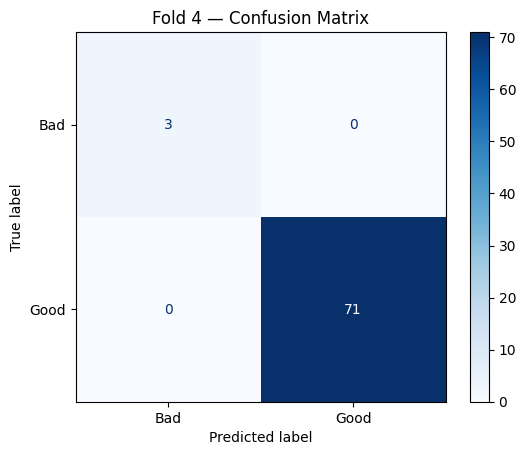

F1 Score: 1.0
     Pressure (PSI)  Welding Time (ms)  Angle (Deg)  Force (N)  Current (A)  \
0                35                200            0       6.82      1081.47   
1                35               1500            0      52.25      2014.73   
2                95                200            0      16.57      1321.93   
3                95                200            0      41.42      1615.83   
4                35               1500            0      63.82      1137.29   
..              ...                ...          ...        ...          ...   
362              60               1200           15      95.61      3040.82   
364              60               1200            0      96.79      4293.96   
365              60               1200            0      97.29      4226.13   
366              60               1200            0      97.29      4311.15   
368              60               1200            0      97.35      3971.85   

     Thickness A (mm)  Thickness B (m


Fold 4
MAE : 121.97551500475087
RMSE: 202.24757354985368
R²  : 0.827982830995991


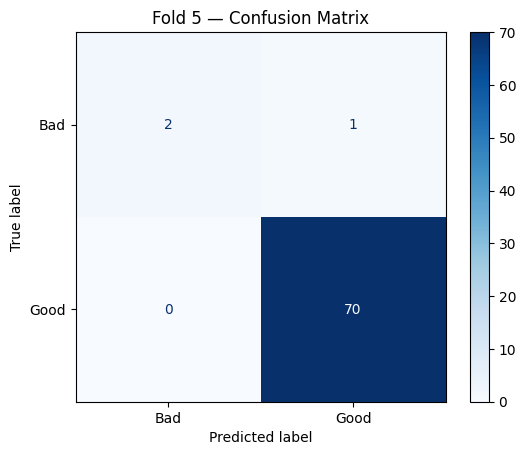

F1 Score: 0.8964539007092198
     Pressure (PSI)  Welding Time (ms)  Angle (Deg)  Force (N)  Current (A)  \
0                35                200            0       6.82      1081.47   
1                35               1500            0      52.25      2014.73   
2                95                200            0      16.57      1321.93   
3                95                200            0      41.42      1615.83   
4                35               1500            0      63.82      1137.29   
..              ...                ...          ...        ...          ...   
360              60               1200           15      95.42      3725.61   
362              60               1200           15      95.61      3040.82   
363              60               1200           15      95.73      3048.16   
364              60               1200            0      96.79      4293.96   
367              60               1200            0      97.12      4738.77   

     Thickness A (mm) 


Fold 5
MAE : 94.38841512497159
RMSE: 140.28915281199554
R²  : 0.7473248248642637


In [ ]:
cross_df = pd.read_csv("data/train_dev_data.csv")
target_column_regression = "PullTest (N)" 

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_predictions = []
fold_true = []
fold_predictions_regression = []
fold_true_regression = []

for fold, (train_index, val_index) in enumerate(skf.split(cross_df["Sample ID"], cross_df["Category"])):
    x_tr, y_tr = get_features_and_target(cross_df.iloc[train_index], target_column_class) 
    x_val, y_val = get_features_and_target(cross_df.iloc[val_index], target_column_class)
    y_train_regression, y_val_regression = get_features_and_target(cross_df.iloc[val_index], target_column_regression)

    classifier = TabPFNClassifier()
    classifier.fit(x_tr,y_tr)

    predictions_class_train = classifier.predict(x_tr)
    predictions_class_dev = classifier.predict(x_val)


    # Plot classification results for this fold
    plot_visualizer_classification(
        y_true=y_val,
        y_pred=predictions_class_dev,
        class_labels=["Bad", "Good"],
        title=f"Fold {fold+1} — Confusion Matrix"
    )


    x_tr.loc[:, "Physical_Inference"] = compute_pullforces(x_tr, y_tr, predictions_class_train) 
    x_val.loc[:, "Physical_Inference"] = compute_pullforces(x_val, y_val, predictions_class_dev)

    y_train_delta = y_train_regression - x_tr['Physical_Inference'] 
    y_dev_delta = y_val_regression - x_val['Physical_Inference']


    x_train_res = x_tr.drop(columns=['Physical_Inference'])
    x_dev_res = x_val.drop(columns=['Physical_Inference'])
    
    regressor = TabPFNRegressor()
    regressor.fit(x_train_res, y_train_delta)

    preds = regressor.predict(x_dev_res)
    final_pred = x_val['Physical_Inference'] + preds

    mae  = mean_absolute_error(y_val_regression, final_pred)
    rmse = np.sqrt(mean_squared_error(y_val_regression, final_pred))
    R2   = r2_score(y_val_regression, final_pred)

    # Categories
    categories= cross_df.iloc[val_index]["Category"].values

    plot_visualizer(
        true_vals=y_val_regression,
        pred_vals=final_pred,
        categories=categories,
        title=f"Fold {fold+1}: True vs Prediction (TabPFN) by Category"
    )

    print(f"\nFold {fold+1}")
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R²  :", R2)

    fold_predictions_regression.append(final_pred)
    fold_true_regression.append(y_val_regression.values)

    fold_predictions.append(predictions_class_dev)
    fold_true.append(y_val.values)

In [26]:
# Final Evaluation over all Folds

y_true_all = np.concatenate(fold_true)
y_pred_all = np.concatenate(fold_predictions)

# F1 Score
f1 = f1_score(y_true_all, y_pred_all, average="macro")
print("F1 Score:", f1)

# Final Evaluation over all Folds
y_true_all_regression = np.concatenate(fold_true_regression)
y_pred_all_regression = np.concatenate(fold_predictions_regression)

mae  = mean_absolute_error(y_true_all_regression, y_pred_all_regression)
rmse = np.sqrt(mean_squared_error(y_true_all_regression, y_pred_all_regression))
R2   = r2_score(y_true_all_regression, y_pred_all_regression)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {R2:.2f}")

F1 Score: 0.9494912624903042
MAE:  119.77
RMSE: 207.50
R²:   0.71
